# MDR-TS v20.9
**Baseline Models — Leave-One-Station-Out (All Stations, derived_9.0)**

**Author:** Kerry Cheon <br>
**Purpose:** Compare regime-switched XGBoost (v20.8) against simpler baselines

---

## Baselines
1. **SMAP Passthrough** — raw satellite value, no model
2. **Ridge (SMAP-only)** — 3 SMAP features, linear regression
3. **Ridge (full BASE)** — all 28 features, linear regression

## 0. Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

import warnings
warnings.filterwarnings("ignore")

print("imports loaded")

imports loaded


## 1. Config

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

VERSION    = "v20"
SUBVERSION = "v20.9"

PROJECT_ROOT = "/Users/kerrycheon/PycharmProjects/MDR-Project"
DATA_ROOT    = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT   = f"{DATA_ROOT}/splits"
OUTPUT_ROOT  = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"
V208_ROOT    = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/v20.8"  # for loading v20.8 results

SPLIT = "derived_9.0"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

ALL_STATIONS = ['BeaverPass_WA_990', 'BurntMountain_WA', 'CayusePass_WA', 'Darrington', 'HartsPass_WA_515', 'MFNooksack_WA_1011', 'MartenRidge_WA_999', 'Paradise_WA', 'Quinault', 'RainyPass_WA_711', 'SCAN_ConradAgRc', 'SCAN_CookFarmFieldD', 'SCAN_JordanValleyCwma', 'SCAN_Lind_1', 'SCAN_OrchardRangeSite', 'SCAN_TableMountain', 'SCAN_Violett', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824', 'USCRN_Arco_17_SW', 'USCRN_Coos_Bay_8_SW', 'USCRN_Corvallis_10_SSW', 'USCRN_Darrington_21_NNE', 'USCRN_Dillon_18_WSW', 'USCRN_John_Day_35_WNW', 'USCRN_Murphy_10_W', 'USCRN_Quinault_4_NE', 'USCRN_Riley_10_WSW', 'USCRN_Spokane_17_SSW', 'USCRN_St_Mary_1_SSW']

# Only 4 stations have SMAP data in all splits
SMAP_STATIONS = ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

TARGET_COL     = "soil_moisture_5cm"

print(f"Random seed:    {SEED}")
print(f"Output:         {OUTPUT_ROOT}")
print(f"SMAP stations:  {len(SMAP_STATIONS)}")
print(f"Stations:       {SMAP_STATIONS}")

Random seed:    42
Output:         /Users/kerrycheon/PycharmProjects/MDR-Project/Models/Temporal/v20/v20.9
SMAP stations:  4
Stations:       ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']


## 2. Feature sets

In [3]:
SMAP_COLS = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",
]

FEATURE_COLS_BASE = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",
    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",
    "A_d_E_SAR_diff_kobs14",
    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",
    "V_rollmean_s2_b11_kobs7",
    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",
    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

print(f"SMAP_COLS:        {len(SMAP_COLS)} features")
print(f"FEATURE_COLS_BASE: {len(FEATURE_COLS_BASE)} features")

SMAP_COLS:        3 features
FEATURE_COLS_BASE: 28 features


## 3. Helper functions

In [4]:
def get_metrics(y_true, y_pred):
    """Compute R2, MAE, RMSE, ubRMSE, bias (matches v20.8)"""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    
    # Filter out NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    if len(y_true) == 0:
        return {"n": 0, "r2": np.nan, "mae": np.nan, "rmse": np.nan, "ubrmse": np.nan, "bias": np.nan}
    
    err = y_true - y_pred
    return {
        "n":      int(len(y_true)),
        "r2":     float(r2_score(y_true, y_pred)),
        "mae":    float(mean_absolute_error(y_true, y_pred)),
        "rmse":   float(root_mean_squared_error(y_true, y_pred)),
        "ubrmse": float(np.std(err)),
        "bias":   float(np.mean(err)),
    }

print("Helper functions defined")

Helper functions defined


## 4. Load splits

In [5]:
train_raw = pd.read_csv(f"{SPLIT_ROOT}/{SPLIT}/train.csv")
val_raw   = pd.read_csv(f"{SPLIT_ROOT}/{SPLIT}/val.csv")
test_raw  = pd.read_csv(f"{SPLIT_ROOT}/{SPLIT}/test.csv")

print("Raw split sizes:")
print(f"  train: {len(train_raw):,}  val: {len(val_raw):,}  test: {len(test_raw):,}")
print(f"Total rows: {len(train_raw) + len(val_raw) + len(test_raw):,}")

Raw split sizes:
  train: 29,362  val: 13,637  test: 20,166
Total rows: 63,165


## 5. LOSO baseline loop

In [6]:
baseline_results = []  # list of dicts — one per holdout station

for HOLDOUT in SMAP_STATIONS:
    print(f"\n{'='*60}")
    print(f"  HOLDOUT: {HOLDOUT}")
    print(f"{'='*60}")

    # ── carve out holdout ──────────────────────────────────────────────────────
    train_df = train_raw[train_raw["station_id"] != HOLDOUT].reset_index(drop=True)
    val_df   = val_raw  [val_raw  ["station_id"] != HOLDOUT].reset_index(drop=True)
    test_df  = test_raw [test_raw ["station_id"] == HOLDOUT].reset_index(drop=True)

    trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

    print(f"  trainval rows: {len(trainval_df):,}  |  test rows: {len(test_df):,}")

    if len(test_df) == 0:
        print(f"  WARNING: no test rows for {HOLDOUT}, skipping")
        continue

    # ── prepare matrices ───────────────────────────────────────────────────────
    X_tv_smap  = trainval_df[SMAP_COLS]
    X_tv_base  = trainval_df[FEATURE_COLS_BASE]
    y_tv       = trainval_df[TARGET_COL].values

    X_test_smap = test_df[SMAP_COLS]
    X_test_base = test_df[FEATURE_COLS_BASE]
    y_test      = test_df[TARGET_COL].values

    # ── Baseline 1: SMAP passthrough (no fit, no model) ────────────────────────
    pred_smap_raw = X_test_base["SMAP_sm_pm_interp_ema02"].values
    m1 = get_metrics(y_test, pred_smap_raw)
    print(f"  [1/3] SMAP passthrough:  R²={m1['r2']:+.4f}  RMSE={m1['rmse']:.4f}")

    # ── Baseline 2: Ridge (SMAP-only) ──────────────────────────────────────────
    pipe_smap = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge",  Ridge(alpha=1.0, random_state=SEED))
    ])
    pipe_smap.fit(X_tv_smap, y_tv)
    pred_ridge_smap = pipe_smap.predict(X_test_smap)
    m2 = get_metrics(y_test, pred_ridge_smap)
    print(f"  [2/3] Ridge (SMAP-only): R²={m2['r2']:+.4f}  RMSE={m2['rmse']:.4f}")

    # ── Baseline 3: Ridge (full BASE) ──────────────────────────────────────────
    pipe_base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge",  Ridge(alpha=1.0, random_state=SEED))
    ])
    pipe_base.fit(X_tv_base, y_tv)
    pred_ridge_base = pipe_base.predict(X_test_base)
    m3 = get_metrics(y_test, pred_ridge_base)
    print(f"  [3/3] Ridge (full BASE): R²={m3['r2']:+.4f}  RMSE={m3['rmse']:.4f}")

    # ── collect results ────────────────────────────────────────────────────────
    baseline_results.append({
        "station": HOLDOUT,
        "smap_passthrough_n": m1["n"],
        "smap_passthrough_r2": m1["r2"],
        "smap_passthrough_mae": m1["mae"],
        "smap_passthrough_rmse": m1["rmse"],
        "smap_passthrough_ubrmse": m1["ubrmse"],
        "smap_passthrough_bias": m1["bias"],
        "ridge_smap_r2": m2["r2"],
        "ridge_smap_mae": m2["mae"],
        "ridge_smap_rmse": m2["rmse"],
        "ridge_smap_ubrmse": m2["ubrmse"],
        "ridge_smap_bias": m2["bias"],
        "ridge_base_r2": m3["r2"],
        "ridge_base_mae": m3["mae"],
        "ridge_base_rmse": m3["rmse"],
        "ridge_base_ubrmse": m3["ubrmse"],
        "ridge_base_bias": m3["bias"],
    })

print("\nBaseline LOSO loop complete")


  HOLDOUT: Darrington


  trainval rows: 40,951  |  test rows: 999
  [1/3] SMAP passthrough:  R²=-14.4594  RMSE=0.3674
  [2/3] Ridge (SMAP-only): R²=-0.8848  RMSE=0.1283
  [3/3] Ridge (full BASE): R²=-42.5887  RMSE=0.6168

  HOLDOUT: Quinault


  trainval rows: 40,839  |  test rows: 1,044
  [1/3] SMAP passthrough:  R²=-34.5577  RMSE=0.4139
  [2/3] Ridge (SMAP-only): R²=+0.0518  RMSE=0.0676
  [3/3] Ridge (full BASE): R²=-1.9455  RMSE=0.1191

  HOLDOUT: SourdoughGulch_WA_985
  trainval rows: 40,809  |  test rows: 906


  [1/3] SMAP passthrough:  R²=+0.1805  RMSE=0.0726
  [2/3] Ridge (SMAP-only): R²=-0.8341  RMSE=0.1086
  [3/3] Ridge (full BASE): R²=-41.2000  RMSE=0.5208

  HOLDOUT: Spokane


  trainval rows: 41,206  |  test rows: 897
  [1/3] SMAP passthrough:  R²=+0.7641  RMSE=0.0558
  [2/3] Ridge (SMAP-only): R²=-0.3959  RMSE=0.1357
  [3/3] Ridge (full BASE): R²=+0.8032  RMSE=0.0510

Baseline LOSO loop complete


## 6. Summary table

In [7]:
baseline_df = pd.DataFrame(baseline_results)

# ── Extract R² values for each baseline ────────────────────────────────────────
summary_r2 = baseline_df[[
    "station",
    "smap_passthrough_r2",
    "ridge_smap_r2",
    "ridge_base_r2",
    "smap_passthrough_rmse",
    "ridge_smap_rmse",
    "ridge_base_rmse",
]].copy()

summary_r2.columns = ["station", "SMAP_raw", "Ridge_SMAP", "Ridge_BASE", "SMAP_raw_rmse", "Ridge_SMAP_rmse", "Ridge_BASE_rmse"]

from IPython.display import display

display(
    summary_r2.style
    .format({
        "SMAP_raw": "{:.4f}", "Ridge_SMAP": "{:.4f}", "Ridge_BASE": "{:.4f}",
        "SMAP_raw_rmse": "{:.4f}", "Ridge_SMAP_rmse": "{:.4f}", "Ridge_BASE_rmse": "{:.4f}"
    })
    .background_gradient(subset=["SMAP_raw", "Ridge_SMAP", "Ridge_BASE"], cmap="Greens")
    .set_caption("v20.9 — LOSO Baseline R² Comparison")
)

baseline_df.to_csv(f"{OUTPUT_ROOT}/loso_baselines_summary.csv", index=False)
print(f"Saved: loso_baselines_summary.csv")

,station,SMAP_raw,Ridge_SMAP,Ridge_BASE,SMAP_raw_rmse,Ridge_SMAP_rmse,Ridge_BASE_rmse
0,Darrington,-14.4594,-0.8848,-42.5887,0.3674,0.1283,0.6168
1,Quinault,-34.5577,0.0518,-1.9455,0.4139,0.0676,0.1191
2,SourdoughGulch_WA_985,0.1805,-0.8341,-41.2000,0.0726,0.1086,0.5208
3,Spokane,0.7641,-0.3959,0.8032,0.0558,0.1357,0.0510


Saved: loso_baselines_summary.csv


## 7. Comparison with v20.8 XGB

In [8]:
# ── Load v20.8 results and filter to SMAP stations ─────────────────────────────
xgb_df = pd.read_csv(f"{V208_ROOT}/loso_all_stations_summary.csv")
xgb_df = xgb_df[xgb_df['station'].isin(SMAP_STATIONS)]

# ── Merge for side-by-side comparison ──────────────────────────────────────────
comparison = baseline_df[["station", "smap_passthrough_r2", "ridge_smap_r2", "ridge_base_r2"]].copy()
comparison.columns = ["station", "SMAP_raw", "Ridge_SMAP", "Ridge_BASE"]
comparison["XGB_regime"] = xgb_df["r2"].values

display(
    comparison.style
    .format({c: "{:.4f}" for c in ["SMAP_raw", "Ridge_SMAP", "Ridge_BASE", "XGB_regime"]})
    .background_gradient(subset=["SMAP_raw", "Ridge_SMAP", "Ridge_BASE", "XGB_regime"], cmap="RdYlGn", vmin=-0.1, vmax=1.0)
    .set_caption("v20.9 — All Baselines + XGB Regime Model (v20.8) — 4 SMAP-covered Stations")
)

comparison.to_csv(f"{OUTPUT_ROOT}/loso_all_models_r2_comparison.csv", index=False)
print(f"Saved: loso_all_models_r2_comparison.csv")

,station,SMAP_raw,Ridge_SMAP,Ridge_BASE,XGB_regime
0,Darrington,-14.4594,-0.8848,-42.5887,0.7215
1,Quinault,-34.5577,0.0518,-1.9455,-1.3578
2,SourdoughGulch_WA_985,0.1805,-0.8341,-41.2000,0.5786
3,Spokane,0.7641,-0.3959,0.8032,0.7206


Saved: loso_all_models_r2_comparison.csv


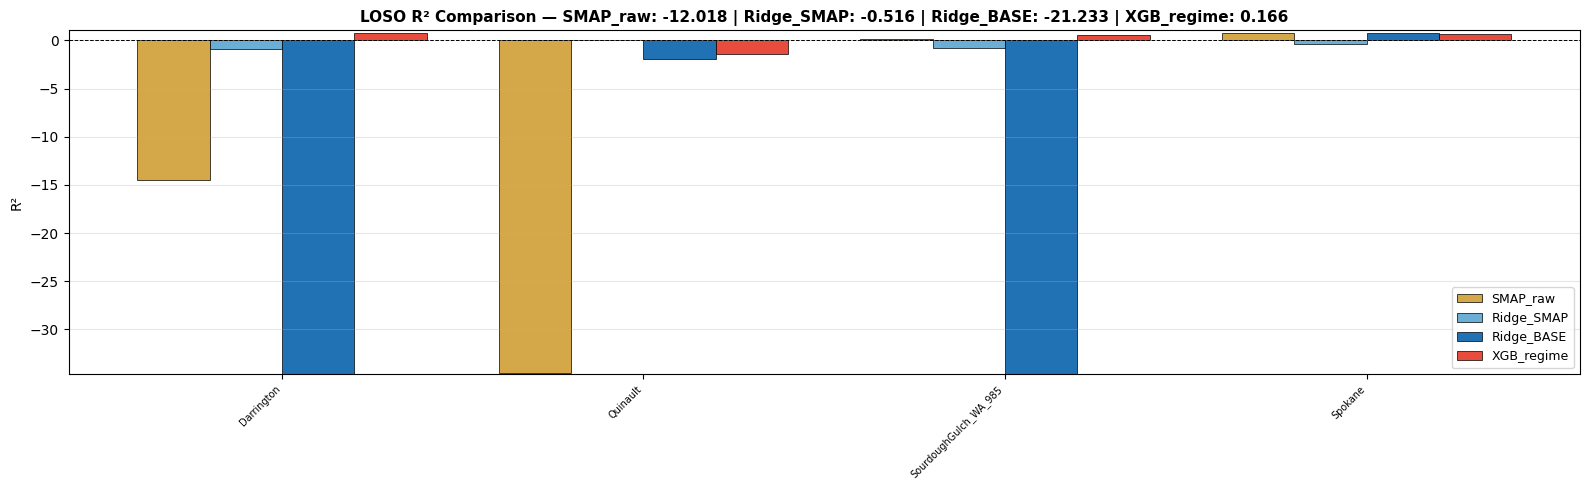


Mean R² by model:
  SMAP_raw       : -12.0181
  Ridge_SMAP     : -0.5157
  Ridge_BASE     : -21.2328
  XGB_regime     : 0.1657


In [9]:
# ── Grouped bar chart: all models side-by-side ─────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

stations = comparison["station"].values
smap_raw = comparison["SMAP_raw"].values
ridge_smap = comparison["Ridge_SMAP"].values
ridge_base = comparison["Ridge_BASE"].values
xgb_regime = comparison["XGB_regime"].values

x = np.arange(len(stations))
width = 0.2

fig, ax = plt.subplots(figsize=(max(16, len(stations) * 0.65), 5))

colors = ["#d4a849", "#6baed6", "#2171b5", "#e74c3c"]
labels = ["SMAP_raw", "Ridge_SMAP", "Ridge_BASE", "XGB_regime"]
bars = [
    ax.bar(x - 1.5*width, smap_raw,   width, label=labels[0], color=colors[0], edgecolor='k', linewidth=0.5),
    ax.bar(x - 0.5*width, ridge_smap, width, label=labels[1], color=colors[1], edgecolor='k', linewidth=0.5),
    ax.bar(x + 0.5*width, ridge_base, width, label=labels[2], color=colors[2], edgecolor='k', linewidth=0.5),
    ax.bar(x + 1.5*width, xgb_regime, width, label=labels[3], color=colors[3], edgecolor='k', linewidth=0.5),
]

ax.set_xticks(x)
ax.set_xticklabels(stations, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('R²', fontsize=10)
ax.set_ylim(min(0, smap_raw.min()) - 0.1, 1.05)
ax.axhline(0, color='k', lw=0.7, linestyle='--')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)

mean_r2 = {
    labels[0]: smap_raw.mean(),
    labels[1]: ridge_smap.mean(),
    labels[2]: ridge_base.mean(),
    labels[3]: xgb_regime.mean(),
}

title_str = f"LOSO R² Comparison — "
title_str += " | ".join([f"{l}: {mean_r2[l]:.3f}" for l in labels])
ax.set_title(title_str, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_ROOT}/loso_baseline_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean R² by model:")
for label in labels:
    print(f"  {label:15s}: {mean_r2[label]:.4f}")